In [1]:
import pandas as pd
PATH = "00_data/"

In [ ]:
# 1. 고객이 얼마나 존재하는가? 96,096명

In [2]:
products = pd.read_csv(f"{PATH}olist_products_dataset.csv", encoding="utf-8-sig")
customers = pd.read_csv(f"{PATH}olist_customers_dataset.csv", encoding="utf-8-sig")
geolocation = pd.read_csv(f"{PATH}olist_geolocation_dataset.csv", encoding="utf-8-sig")
order_items = pd.read_csv(f"{PATH}olist_order_items_dataset.csv", encoding="utf-8-sig")
payments = pd.read_csv(f"{PATH}olist_order_payments_dataset.csv", encoding="utf-8-sig")
reviews = pd.read_csv(f"{PATH}olist_order_reviews_dataset.csv", encoding="utf-8-sig")
orders = pd.read_csv(f"{PATH}olist_orders_dataset.csv", encoding="utf-8-sig")
sellers = pd.read_csv(f"{PATH}olist_sellers_dataset.csv", encoding="utf-8-sig")
category_name = pd.read_csv(f"{PATH}product_category_name_translation.csv", encoding="utf-8-sig")

In [80]:
payments

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


In [3]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [4]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [10]:
# 컬럼에 중복되어지는 값이 존재 => 최대 17개까지 중복
# 사용자를 식별하기 위한 고유 ID

customers["customer_unique_id"].value_counts().max()

17

In [11]:
# 중복이 한개도 없음
# 주문이 발생할 때마다 신규로 생성되는 고객 ID

customers["customer_id"].value_counts().max()

1

In [12]:
customers["customer_id"].nunique()

99441

In [13]:
customers["customer_unique_id"].nunique()

96096

In [ ]:
# 지금까지 실제 구매한 고객 수 : 96,096

In [23]:
# 2. 고객은 주로 어디에 거주하는가? sao paulo 14,984

In [15]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [34]:
customers_location = customers.groupby("customer_city")["customer_unique_id"].nunique().sort_values(ascending=False)

In [35]:
customer_location_top20 = customers_location.head(20)

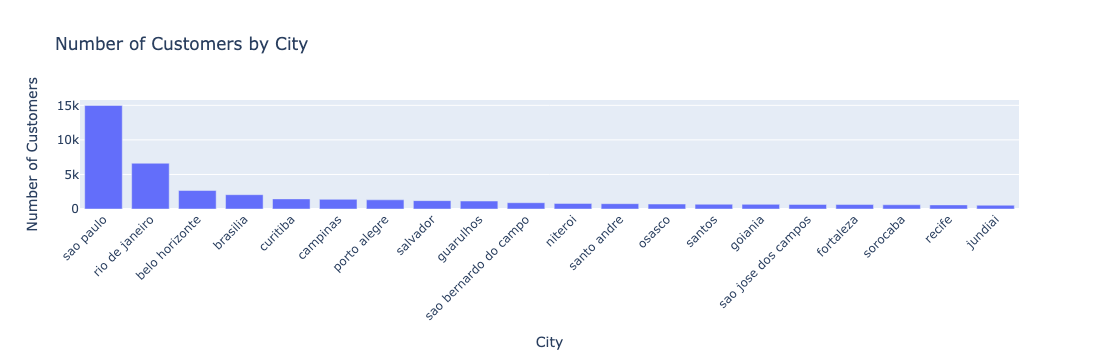

In [36]:
import plotly.express as px

fig = px.bar(
    x=customer_location_top20.index,
    y=customer_location_top20.values,
    title="Number of Customers by City",
    labels={"x": "City", "y": "Number of Customers"}
)

fig.update_layout(xaxis_tickangle=-45)

fig.show()

In [39]:
top20_customer_locations = customer_location_top20.index
top20_customer_locations

Index(['sao paulo', 'rio de janeiro', 'belo horizonte', 'brasilia', 'curitiba',
       'campinas', 'porto alegre', 'salvador', 'guarulhos',
       'sao bernardo do campo', 'niteroi', 'santo andre', 'osasco', 'santos',
       'goiania', 'sao jose dos campos', 'fortaleza', 'sorocaba', 'recife',
       'jundiai'],
      dtype='object', name='customer_city')

In [43]:
for index, location in enumerate(top20_customer_location) :
    print("TOP", index + 1, location)

TOP 1 sao paulo
TOP 2 rio de janeiro
TOP 3 belo horizonte
TOP 4 brasilia
TOP 5 curitiba
TOP 6 campinas
TOP 7 porto alegre
TOP 8 salvador
TOP 9 guarulhos
TOP 10 sao bernardo do campo
TOP 11 niteroi
TOP 12 santo andre
TOP 13 osasco
TOP 14 santos
TOP 15 goiania
TOP 16 sao jose dos campos
TOP 17 fortaleza
TOP 18 sorocaba
TOP 19 recife
TOP 20 jundiai


In [73]:
# 3. 고객은 주로 어떤 결제방법을 사용할까? credit_card 76,505

In [45]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [46]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [47]:
payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [48]:
payments["payment_type"].unique()

array(['credit_card', 'boleto', 'voucher', 'debit_card', 'not_defined'],
      dtype=object)

In [50]:
payments = payments[payments["payment_type"] != 'not_defined']

In [52]:
payments["payment_type"].unique()

array(['credit_card', 'boleto', 'voucher', 'debit_card'], dtype=object)

In [58]:
payment_type_count = payments.groupby("payment_type")["order_id"].nunique().sort_values(ascending=False)
payment_type_count

payment_type
credit_card    76505
boleto         19784
voucher         3866
debit_card      1528
Name: order_id, dtype: int64

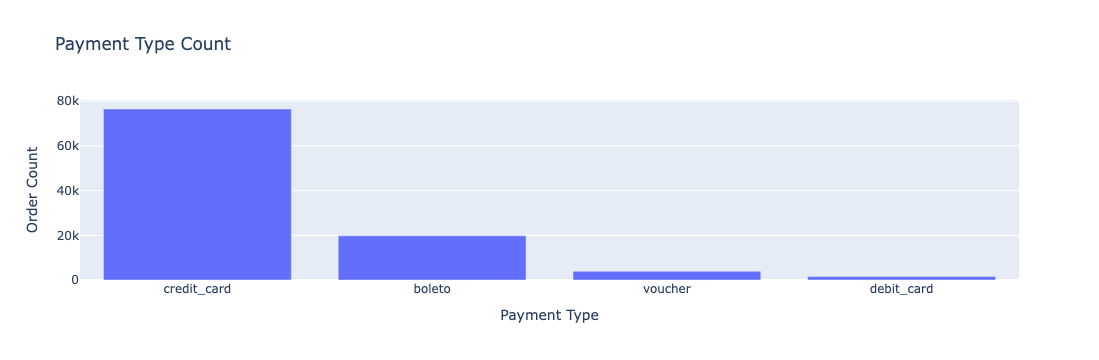

In [62]:
import plotly.express as px

fig = px.bar(
    x=payment_type_count.index,
    y=payment_type_count.values,
    title="Payment Type Count",
    labels= {"x": "Payment Type", "y": "Order Count"}
)

fig.show()

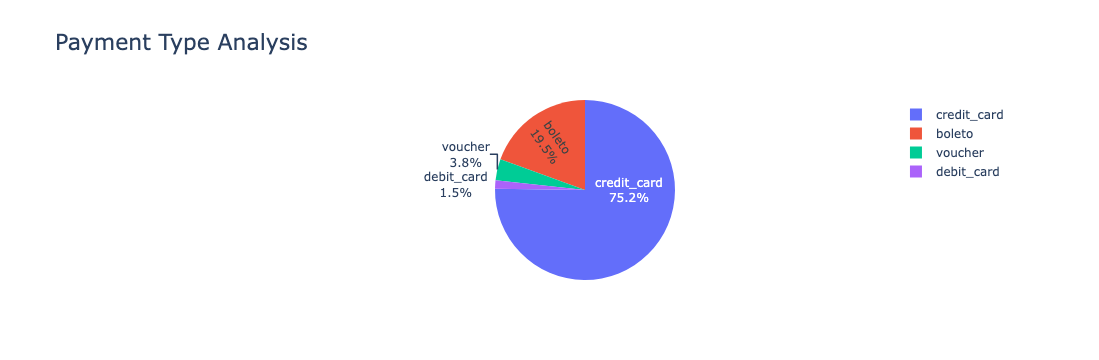

In [72]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Pie(
        labels=payment_type_count.index,
        values=payment_type_count.values,
        textinfo="label+percent",
        insidetextorientation="radial"
    )
)

fig.update_layout(
    {
        "title": {
            "text":"Payment Type Analysis",
            "font": {
                "size": 22
            }
        }
    }
)

fig.show()

In [81]:
# 4. 월 평균 거래금액은 얼마일까?

In [5]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [6]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [85]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [108]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [88]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [3]:
orders = orders.dropna()

In [4]:
orders.isnull().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64

In [5]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96461 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       96461 non-null  object
 1   customer_id                    96461 non-null  object
 2   order_status                   96461 non-null  object
 3   order_purchase_timestamp       96461 non-null  object
 4   order_approved_at              96461 non-null  object
 5   order_delivered_carrier_date   96461 non-null  object
 6   order_delivered_customer_date  96461 non-null  object
 7   order_estimated_delivery_date  96461 non-null  object
dtypes: object(8)
memory usage: 6.6+ MB


In [93]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
Index: 103883 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103883 non-null  object 
 1   payment_sequential    103883 non-null  int64  
 2   payment_type          103883 non-null  object 
 3   payment_installments  103883 non-null  int64  
 4   payment_value         103883 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.8+ MB


In [95]:
orders["order_id"].value_counts().max()

1

In [9]:
payments["order_id"].value_counts()

order_id
fa65dad1b0e818e3ccc5cb0e39231352    29
ccf804e764ed5650cd8759557269dc13    26
285c2e15bebd4ac83635ccc563dc71f4    22
895ab968e7bb0d5659d16cd74cd1650c    21
fedcd9f7ccdc8cba3a18defedd1a5547    19
                                    ..
6d2a30c9b7dcee3ed507dc9a601f99e7     1
a7737f6d9208dd56ea498a322ed3c37f     1
646e62df54f3e236eb6d5ff3b31429b8     1
e115da7a49ec2acf622e1f31da65cfb9     1
28bbae6599b09d39ca406b747b6632b1     1
Name: count, Length: 99440, dtype: int64

In [99]:
payments[payments["order_id"] == "fa65dad1b0e818e3ccc5cb0e39231352"]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
4885,fa65dad1b0e818e3ccc5cb0e39231352,27,voucher,1,66.02
9985,fa65dad1b0e818e3ccc5cb0e39231352,4,voucher,1,29.16
14321,fa65dad1b0e818e3ccc5cb0e39231352,1,voucher,1,3.71
17274,fa65dad1b0e818e3ccc5cb0e39231352,9,voucher,1,1.08
19565,fa65dad1b0e818e3ccc5cb0e39231352,10,voucher,1,12.86
23074,fa65dad1b0e818e3ccc5cb0e39231352,2,voucher,1,8.51
24879,fa65dad1b0e818e3ccc5cb0e39231352,25,voucher,1,3.68
28330,fa65dad1b0e818e3ccc5cb0e39231352,5,voucher,1,0.66
29648,fa65dad1b0e818e3ccc5cb0e39231352,6,voucher,1,5.02
32519,fa65dad1b0e818e3ccc5cb0e39231352,11,voucher,1,4.03


In [6]:
payments = payments.groupby("order_id").sum()

In [7]:
payments[payments.index == "fa65dad1b0e818e3ccc5cb0e39231352"]

,payment_sequential,payment_type,payment_installments,payment_value
order_id,,,,
fa65dad1b0e818e3ccc5cb0e39231352,435,vouchervouchervouchervouchervouchervouchervouc...,29,457.99


In [107]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99437 entries, 00010242fe8c5a6d1ba2dd792cb16214 to fffe41c64501cc87c801fd61db3f6244
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   payment_sequential    99437 non-null  int64  
 1   payment_type          99437 non-null  object 
 2   payment_installments  99437 non-null  int64  
 3   payment_value         99437 non-null  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 3.8+ MB


In [8]:
# merged_order = pd.merge(orders, payments, on="order_id", how="left")
merged_order = pd.merge(orders, payments, on="order_id")

In [13]:
merged_order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96460 entries, 0 to 96459
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       96460 non-null  object 
 1   customer_id                    96460 non-null  object 
 2   order_status                   96460 non-null  object 
 3   order_purchase_timestamp       96460 non-null  object 
 4   order_approved_at              96460 non-null  object 
 5   order_delivered_carrier_date   96460 non-null  object 
 6   order_delivered_customer_date  96460 non-null  object 
 7   order_estimated_delivery_date  96460 non-null  object 
 8   payment_sequential             96460 non-null  int64  
 9   payment_type                   96460 non-null  object 
 10  payment_installments           96460 non-null  int64  
 11  payment_value                  96460 non-null  float64
dtypes: float64(1), int64(2), object(9)
memory usag

In [14]:
merged_order

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,6,credit_cardvouchervoucher,3,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,boleto,1,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,credit_card,3,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,credit_card,1,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,credit_card,1,28.62
...,...,...,...,...,...,...,...,...,...,...,...,...
96455,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00,1,credit_card,3,85.08
96456,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,1,credit_card,3,195.00
96457,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,1,credit_card,5,271.01
96458,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,1,credit_card,4,441.16


In [15]:
merged_order[merged_order["order_id"] == "e481f51cbdc54678b7cc49136f2d6af7"]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,6,credit_cardvouchervoucher,3,38.71


In [ ]:
# 현 데이터에서는 날짜가 특정한 기준에 따라 월별 정리되지 않은 상황
# 특정 월별 집합
# pandas는 날짜와 관련 타입 정의 => 날짜타입을 사용할 수만 있다면, 해당 타입에서 쓸 수 있는 함수, 속성 => 특정 월별 집합

In [16]:
merged_order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96460 entries, 0 to 96459
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       96460 non-null  object 
 1   customer_id                    96460 non-null  object 
 2   order_status                   96460 non-null  object 
 3   order_purchase_timestamp       96460 non-null  object 
 4   order_approved_at              96460 non-null  object 
 5   order_delivered_carrier_date   96460 non-null  object 
 6   order_delivered_customer_date  96460 non-null  object 
 7   order_estimated_delivery_date  96460 non-null  object 
 8   payment_sequential             96460 non-null  int64  
 9   payment_type                   96460 non-null  object 
 10  payment_installments           96460 non-null  int64  
 11  payment_value                  96460 non-null  float64
dtypes: float64(1), int64(2), object(9)
memory usag

In [17]:
import pandas as pd

df = pd.DataFrame({"order": ["2020-01-01 07:10:00",
                             "2020-01-08 07:20:00",
                             "2020-02-20 11:20:00",
                             "2020-02-20 04:40:50",
                             "2020-02-28 12:10:20",
                             "2019-01-10 17:23:50",
                             "2019-06-20 22:27:50"]})

In [20]:
df

,order
0,2020-01-01 07:10:00
1,2020-01-08 07:20:00
2,2020-02-20 11:20:00
3,2020-02-20 04:40:50
4,2020-02-28 12:10:20
5,2019-01-10 17:23:50
6,2019-06-20 22:27:50


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   order   7 non-null      object
dtypes: object(1)
memory usage: 188.0+ bytes


In [ ]:
# 문자열(object) 형태의 데이터 타입 -> 시간 타입 (datetime64)
# 2025-01-06 = 25-01-06 = 25-1-16 = 25-1-6
# time25"01'01' twenty,,,,,
# to_datetime(Series 변수 = order, format=, errors=)
# ignore : 무시, raise : 출력, coerce : NaT 결측치 값으로 변경 후 실행

%y : 연도를 축약해서 2자리로
%Y : 연도를 축약하지 않은 상태 4자리로
%m : 월을 2자리로
%d : 일을 2자리로
%H : 24시간을 기준 00~23
%M : 분을 2자리로
%S : 초를 2자리로

In [21]:
df["order"]= pd.to_datetime(df["order"], format="%Y-%m-%d %H:%M:%S", errors="raise")

In [22]:
df

,order
0,2020-01-01 07:10:00
1,2020-01-08 07:20:00
2,2020-02-20 11:20:00
3,2020-02-20 04:40:50
4,2020-02-28 12:10:20
5,2019-01-10 17:23:50
6,2019-06-20 22:27:50


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   order   7 non-null      datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 188.0 bytes


In [9]:
merged_order["order_purchase_timestamp"] = pd.to_datetime(merged_order["order_purchase_timestamp"], format="%Y-%m-%d %H:%M:%S", errors="raise")

In [25]:
merged_order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96460 entries, 0 to 96459
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96460 non-null  object        
 1   customer_id                    96460 non-null  object        
 2   order_status                   96460 non-null  object        
 3   order_purchase_timestamp       96460 non-null  datetime64[ns]
 4   order_approved_at              96460 non-null  object        
 5   order_delivered_carrier_date   96460 non-null  object        
 6   order_delivered_customer_date  96460 non-null  object        
 7   order_estimated_delivery_date  96460 non-null  object        
 8   payment_sequential             96460 non-null  int64         
 9   payment_type                   96460 non-null  object        
 10  payment_installments           96460 non-null  int64         
 11  payment_value  

In [10]:
merged_order_payment_date = merged_order[["order_purchase_timestamp", "payment_value"]].copy()

In [11]:
merged_order_payment_date.head()

,order_purchase_timestamp,payment_value
0,2017-10-02 10:56:33,38.71
1,2018-07-24 20:41:37,141.46
2,2018-08-08 08:38:49,179.12
3,2017-11-18 19:28:06,72.20
4,2018-02-13 21:18:39,28.62


In [35]:
merged_order_payment_date.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96460 entries, 0 to 96459
Data columns (total 2 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   order_purchase_timestamp  96460 non-null  datetime64[ns]
 1   payment_value             96460 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 1.5 MB


In [29]:
merged_order_payment_date = merged_order_payment_date.set_index("order_purchase_timestamp")

In [32]:
merged_order_payment_date

,payment_value
order_purchase_timestamp,
2017-10-02 10:56:33,38.71
2018-07-24 20:41:37,141.46
2018-08-08 08:38:49,179.12
2017-11-18 19:28:06,72.20
2018-02-13 21:18:39,28.62
...,...
2017-03-09 09:54:05,85.08
2018-02-06 12:58:58,195.00
2017-08-27 14:46:43,271.01


In [ ]:
# 일별 나눠져있는 날짜 -> 월별
# groupby (중복해서 작성된 요소를 하나의 그룹 합칠 수 있음)

In [ ]:
# groupby > Grouper (*세부적으로 그룹의 조건 생성 적용)
# 데이터프레임.groupby(pd.Grouper(key="그룹화를 하려고하는 컬럼명", freq="세부기준"))

ME : 월간
QE : 분기
YE : 연간
D : 일일
h : 시간
min : 분당
s : 초당

In [36]:
merged_order_month_sum = merged_order_payment_date.groupby(pd.Grouper(key="order_purchase_timestamp", freq="ME")).sum()

In [37]:
merged_order_month_sum

,payment_value
order_purchase_timestamp,
2016-10-31,47271.20
2016-11-30,0.00
2016-12-31,19.62
2017-01-31,127430.74
2017-02-28,269458.98
2017-03-31,414369.39
2017-04-30,390952.18
2017-05-31,566872.73
2017-06-30,490225.60


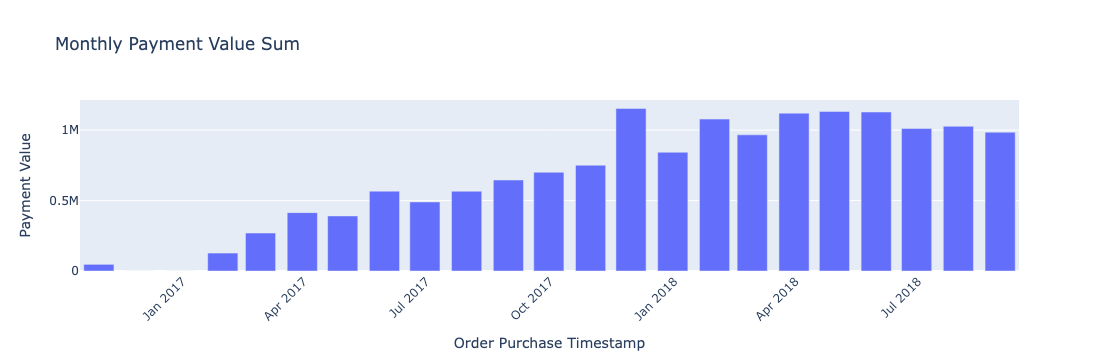

In [42]:
import plotly.express as px

fig = px.bar(
    x=merged_order_month_sum.index,
    y=merged_order_month_sum["payment_value"],
    title="Monthly Payment Value Sum",
    labels={
        "x": "Order Purchase Timestamp",
        "y": "Payment Value"
    }
)

fig.update_layout(xaxis_tickangle=-45)

fig.show()

In [44]:
merged_order_month_sum["payment_value"].mean()

np.float64(670420.9934782608)

In [46]:
merged_order_month_sum["payment_value"][3:]

order_purchase_timestamp
2017-01-31     127430.74
2017-02-28     269458.98
2017-03-31     414369.39
2017-04-30     390952.18
2017-05-31     566872.73
2017-06-30     490225.60
2017-07-31     566403.93
2017-08-31     646000.61
2017-09-30     700976.01
2017-10-31     751140.27
2017-11-30    1153393.22
2017-12-31     843199.17
2018-01-31    1078606.86
2018-02-28     966554.97
2018-03-31    1120678.00
2018-04-30    1132933.95
2018-05-31    1128836.69
2018-06-30    1011561.35
2018-07-31    1027383.10
2018-08-31     985414.28
Freq: ME, Name: payment_value, dtype: float64

In [47]:
merged_order_month_sum["payment_value"][3:].mean()

np.float64(768619.6014999999)

In [48]:
merged_order_month_sum[merged_order_month_sum["payment_value"] == merged_order_month_sum["payment_value"].max()]

,payment_value
order_purchase_timestamp,
2017-11-30,1153393.22


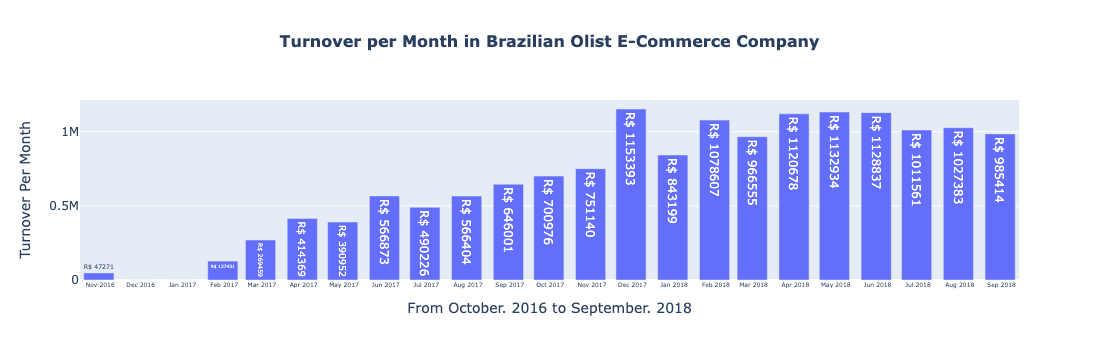

In [72]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=merged_order_month_sum.index,
        y=merged_order_month_sum["payment_value"],
        text=merged_order_month_sum["payment_value"],
        textposition="auto",
        texttemplate="R$ %{y:.0f}"
    )
)

fig.update_layout(
    {
        # "title": "<b>Turnover per Month in Brazilian Olist E-Commerce Company</b>"
        "title": {
            "text": "<b>Turnover per Month in Brazilian Olist E-Commerce Company</b>",
            "x": 0.5,
            "y": 0.9,
            "font": {
                "size": 16
            }
        },
        "xaxis": {
            "title": "From October. 2016 to September. 2018",
            "showticklabels": True,
            "dtick": "M1",
            "tickfont": {
                "size": 6
            }
        },
        "yaxis": {
            "title": "Turnover Per Month"
        }
    }
)

fig.show()

In [73]:
merged_order_month_sum_from2017 = merged_order_month_sum[merged_order_month_sum.index > "2017-01-01"]

In [74]:
merged_order_month_sum_from2017

,payment_value
order_purchase_timestamp,
2017-01-31,127430.74
2017-02-28,269458.98
2017-03-31,414369.39
2017-04-30,390952.18
2017-05-31,566872.73
2017-06-30,490225.60
2017-07-31,566403.93
2017-08-31,646000.61
2017-09-30,700976.01


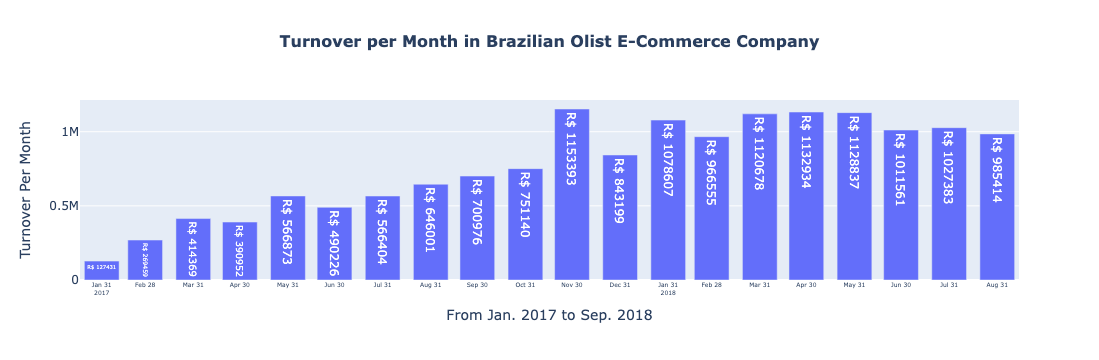

In [77]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=merged_order_month_sum_from2017.index,
        y=merged_order_month_sum_from2017["payment_value"],
        text=merged_order_month_sum["payment_value"],
        textposition="auto",
        texttemplate="R$ %{y:.0f}"
    )
)

fig.update_layout(
    {
        # "title": "<b>Turnover per Month in Brazilian Olist E-Commerce Company</b>"
        "title": {
            "text": "<b>Turnover per Month in Brazilian Olist E-Commerce Company</b>",
            "x": 0.5,
            "y": 0.9,
            "font": {
                "size": 16
            }
        },
        "xaxis": {
            "title": "From Jan. 2017 to Sep. 2018",
            "showticklabels": True,
            "tick0": "2017-01-31",
            "dtick": "M1",
            "tickfont": {
                "size": 6
            }
        },
        "yaxis": {
            "title": "Turnover Per Month"
        }
    }
)

fig.show()

In [78]:
import plotly.io as pio

pio.templates

Templates configuration
-----------------------
    Default template: 'plotly'
    Available templates:
        ['ggplot2', 'seaborn', 'simple_white', 'plotly',
         'plotly_white', 'plotly_dark', 'presentation', 'xgridoff',
         'ygridoff', 'gridon', 'none']

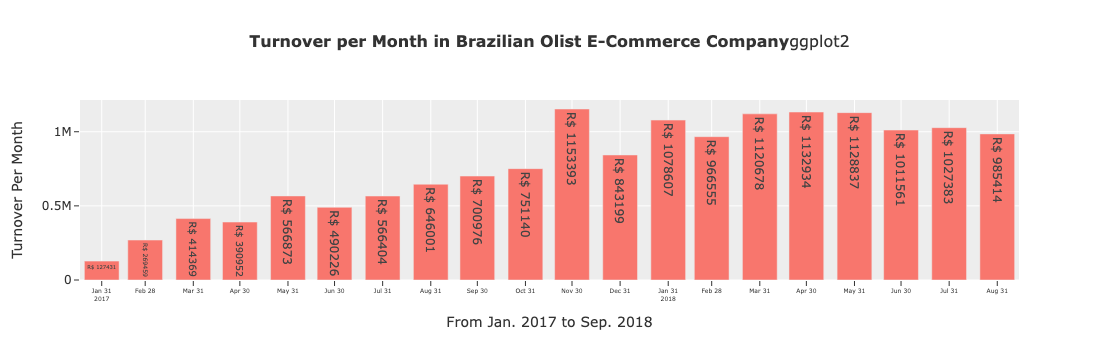

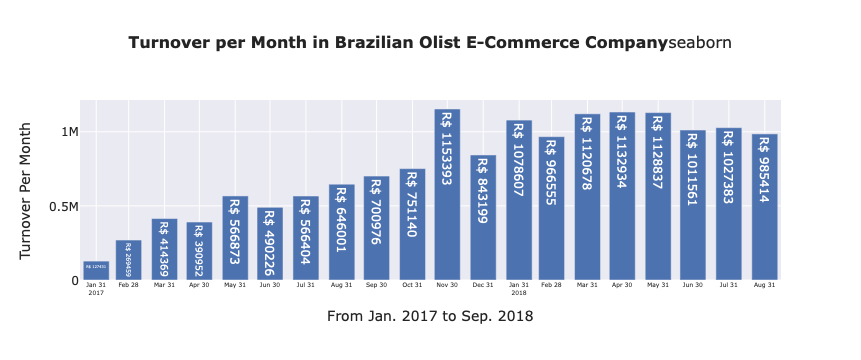

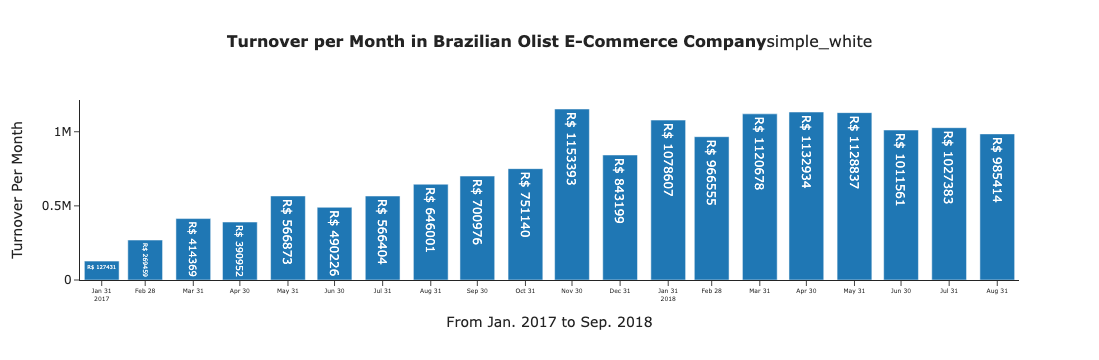

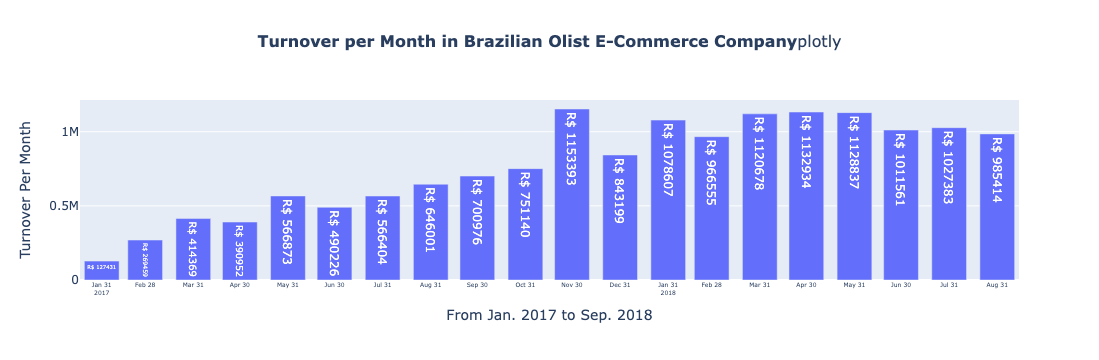

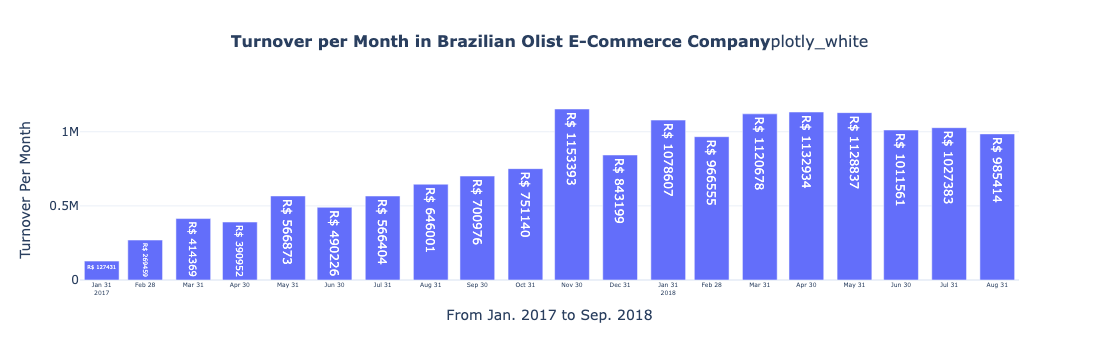

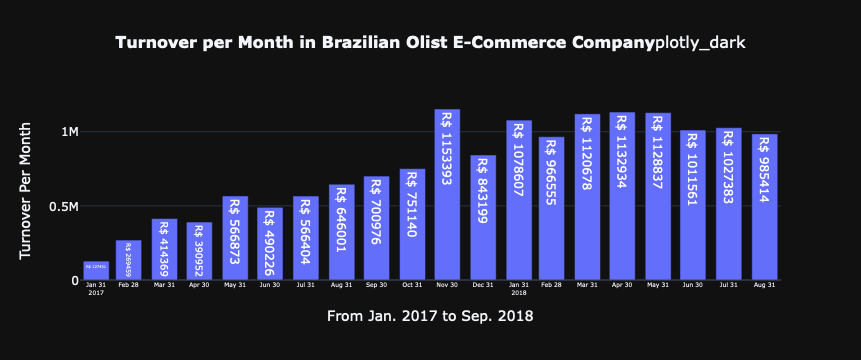

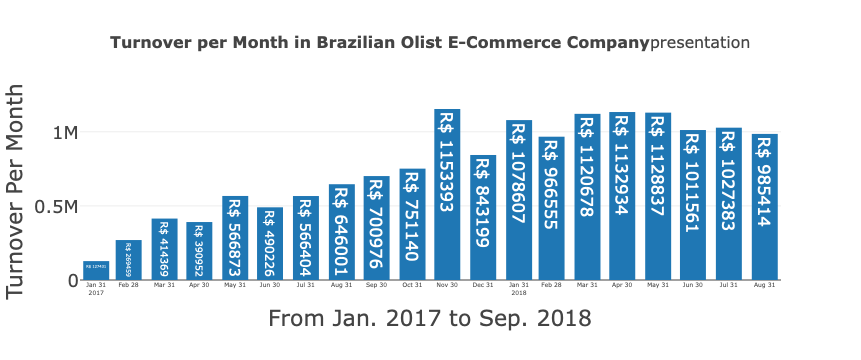

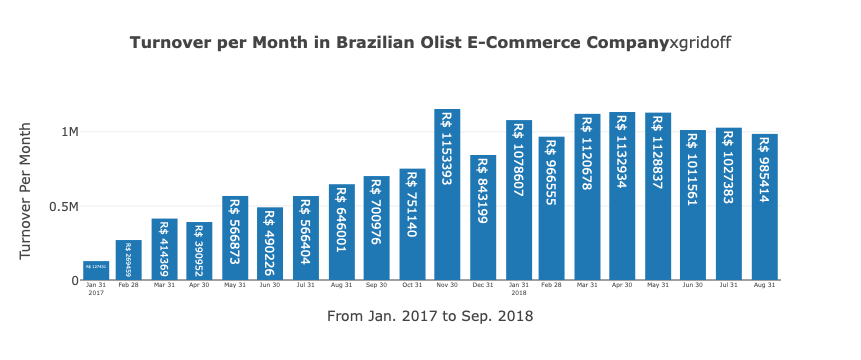

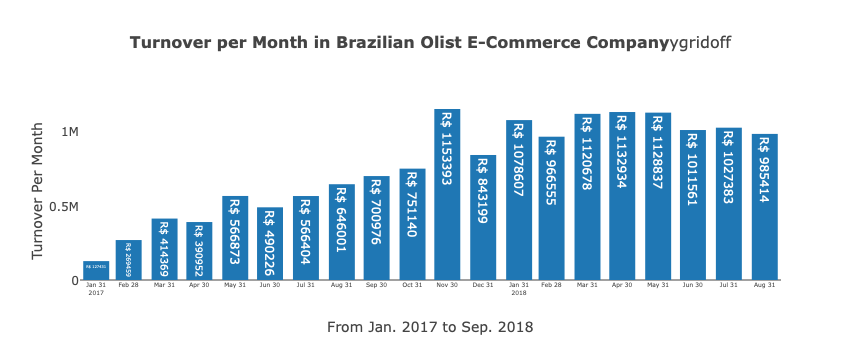

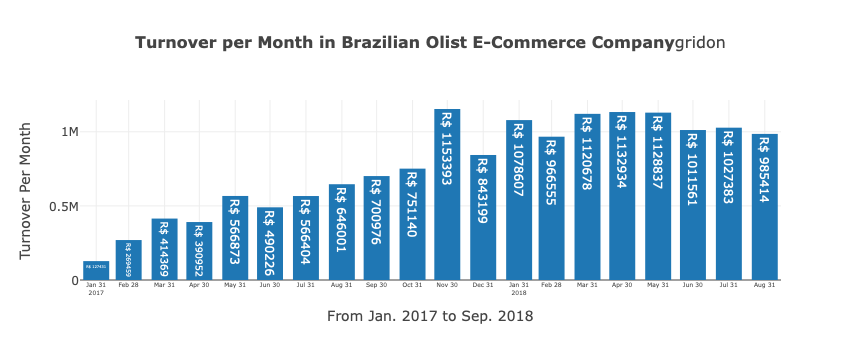

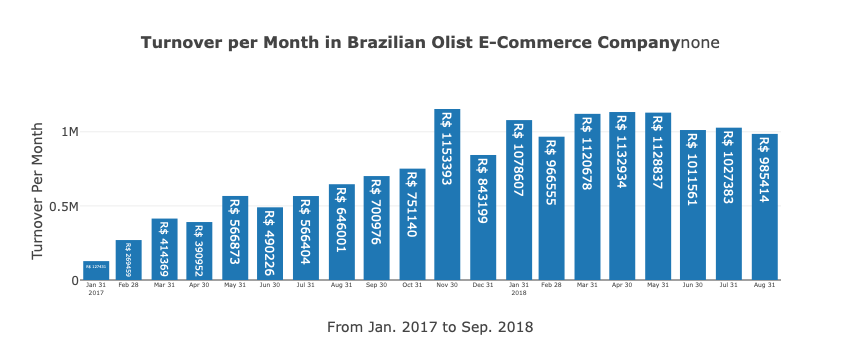

In [86]:
import plotly.graph_objects as go

for template in pio.templates :
    fig = go.Figure()
    
    fig.add_trace(
        go.Bar(
            x=merged_order_month_sum_from2017.index,
            y=merged_order_month_sum_from2017["payment_value"],
            text=merged_order_month_sum["payment_value"],
            textposition="auto",
            texttemplate="R$ %{y:.0f}"
        )
    )
    
    fig.update_layout(
        {
            # "title": "<b>Turnover per Month in Brazilian Olist E-Commerce Company</b>"
            "title": {
                "text": "<b>Turnover per Month in Brazilian Olist E-Commerce Company</b>" + template,
                "x": 0.5,
                "y": 0.9,
                "font": {
                    "size": 16
                }
            },
            "xaxis": {
                "title": "From Jan. 2017 to Sep. 2018",
                "showticklabels": True,
                "tick0": "2017-01-31",
                "dtick": "M1",
                "tickfont": {
                    "size": 6
                }
            },
            "yaxis": {
                "title": "Turnover Per Month"
            },
            "template": template
        }
    )
    
    fig.show()

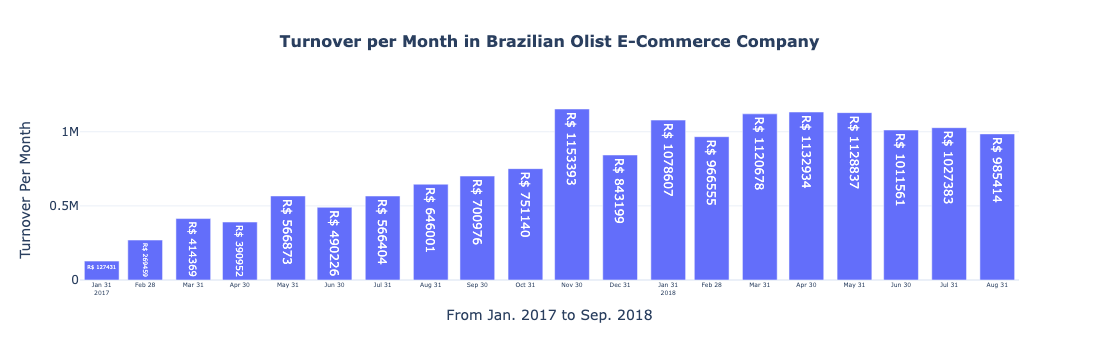

In [87]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=merged_order_month_sum_from2017.index,
        y=merged_order_month_sum_from2017["payment_value"],
        text=merged_order_month_sum["payment_value"],
        textposition="auto",
        texttemplate="R$ %{y:.0f}"
    )
)

fig.update_layout(
    {
        # "title": "<b>Turnover per Month in Brazilian Olist E-Commerce Company</b>"
        "title": {
            "text": "<b>Turnover per Month in Brazilian Olist E-Commerce Company</b>",
            "x": 0.5,
            "y": 0.9,
            "font": {
                "size": 16
            }
        },
        "xaxis": {
            "title": "From Jan. 2017 to Sep. 2018",
            "showticklabels": True,
            "tick0": "2017-01-31",
            "dtick": "M1",
            "tickfont": {
                "size": 6
            }
        },
        "yaxis": {
            "title": "Turnover Per Month"
        },
        "template": "plotly_white"
    }
)

fig.show()

In [91]:
colors = ["#03588c"] * len(merged_order_month_sum_from2017.index)
colors[10] = "#f24472"
colors

['#03588c',
 '#03588c',
 '#03588c',
 '#03588c',
 '#03588c',
 '#03588c',
 '#03588c',
 '#03588c',
 '#03588c',
 '#03588c',
 '#f24472',
 '#03588c',
 '#03588c',
 '#03588c',
 '#03588c',
 '#03588c',
 '#03588c',
 '#03588c',
 '#03588c',
 '#03588c']

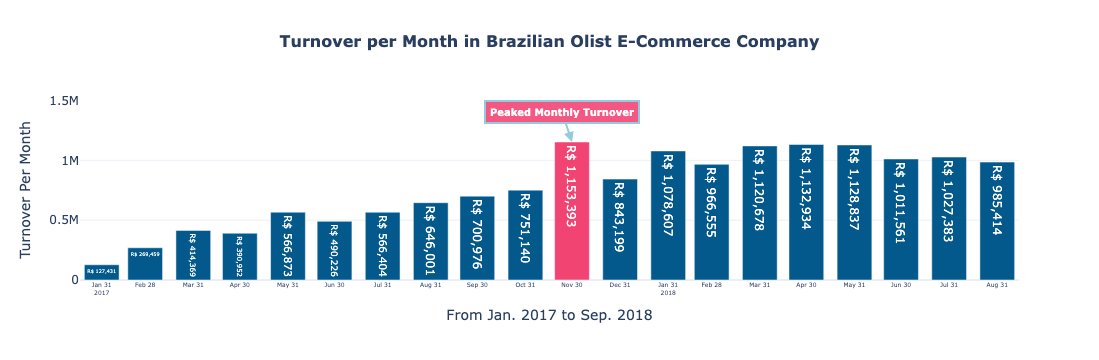

In [111]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=merged_order_month_sum_from2017.index,
        y=merged_order_month_sum_from2017["payment_value"],
        text=merged_order_month_sum["payment_value"],
        textposition="auto",
        texttemplate="R$ %{y:,.0f}",
        marker_color=colors
    )
)

fig.update_layout(
    {
        # "title": "<b>Turnover per Month in Brazilian Olist E-Commerce Company</b>"
        "title": {
            "text": "<b>Turnover per Month in Brazilian Olist E-Commerce Company</b>",
            "x": 0.5,
            "y": 0.9,
            "font": {
                "size": 16
            }
        },
        "xaxis": {
            "title": "From Jan. 2017 to Sep. 2018",
            "showticklabels": True,
            "tick0": "2017-01-31",
            "dtick": "M1",
            "tickfont": {
                "size": 6
            }
        },
        "yaxis": {
            "title": "Turnover Per Month"
        },
        "template": "plotly_white"
    }
)

fig.add_annotation(
    x="2017-11-30",
    y=1153393,
    text="<b>Peaked Monthly Turnover</b>",
    # font={
    #     "size":10
    # },
    font=dict(size=10, color="#fff"),
    bgcolor="#f22e62",
    bordercolor="#77bdd9",
    borderwidth=2,
    borderpad=4,
    opacity=0.8,
    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowwidth=2,
    arrowcolor="#77bdd9",
)

fig.show()

In [112]:
merged_order_date_sum = merged_order_payment_date.groupby(pd.Grouper(key="order_purchase_timestamp", freq="D")).sum()

In [113]:
merged_order_date_sum

,payment_value
order_purchase_timestamp,
2016-10-03,595.14
2016-10-04,9821.42
2016-10-05,7209.50
2016-10-06,6733.52
2016-10-07,7096.69
...,...
2018-08-25,11737.76
2018-08-26,9304.00
2018-08-27,6111.60


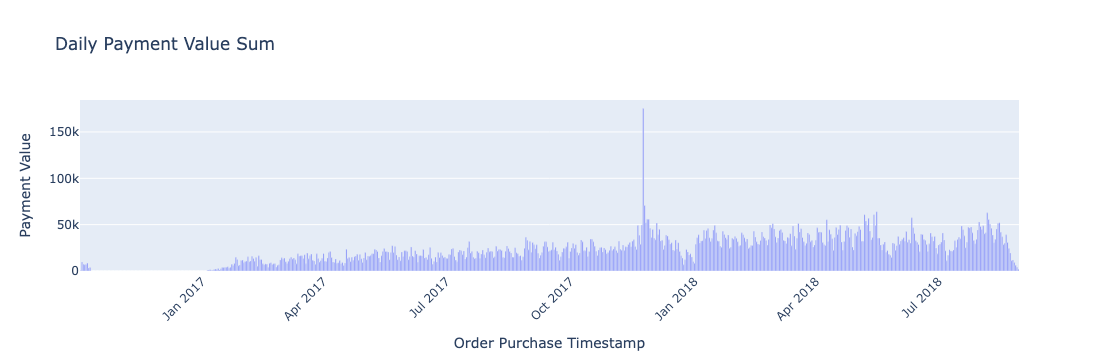

In [119]:
import plotly.express as px

fig = px.bar(
    x=merged_order_date_sum.index,
    y=merged_order_date_sum["payment_value"],
    title="Daily Payment Value Sum",
    labels={
        "x": "Order Purchase Timestamp",
        "y": "Payment Value"
    }
)

fig.update_layout(
    xaxis_tickangle=-45
)

fig.show()

In [121]:
merged_order_payment_date = merged_order[["order_purchase_timestamp", "payment_value"]].copy()

In [122]:
merged_order_payment_date.head()

,order_purchase_timestamp,payment_value
0,2017-10-02 10:56:33,38.71
1,2018-07-24 20:41:37,141.46
2,2018-08-08 08:38:49,179.12
3,2017-11-18 19:28:06,72.20
4,2018-02-13 21:18:39,28.62


In [123]:
merged_order_payment_date.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96460 entries, 0 to 96459
Data columns (total 2 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   order_purchase_timestamp  96460 non-null  datetime64[ns]
 1   payment_value             96460 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 1.5 MB


In [129]:
dir(merged_order_payment_date["order_purchase_timestamp"].dt)

['__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__frozen',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_accessors',
 '_add_delegate_accessors',
 '_constructor',
 '_delegate_method',
 '_delegate_property_get',
 '_delegate_property_set',
 '_dir_additions',
 '_dir_deletions',
 '_freeze',
 '_get_values',
 '_hidden_attrs',
 '_parent',
 '_reset_cache',
 'as_unit',
 'ceil',
 'date',
 'day',
 'day_name',
 'day_of_week',
 'day_of_year',
 'dayofweek',
 'dayofyear',
 'days_in_month',
 'daysinmonth',
 'floor',
 'freq',
 'hour',
 'is_leap_year',
 'is_month_end',
 'is_month_start',
 'is_quarter_end',
 'is_quarter_start',
 'is_year_end',
 'is

In [133]:
merged_order_payment_date["order_purchase_timestamp"].dt.quarter

0        4
1        3
2        3
3        4
4        1
        ..
96455    1
96456    1
96457    3
96458    1
96459    1
Name: order_purchase_timestamp, Length: 96460, dtype: int32

In [12]:
merged_order_payment_date["year"] = merged_order_payment_date["order_purchase_timestamp"].dt.year
merged_order_payment_date["month"] = merged_order_payment_date["order_purchase_timestamp"].dt.month
merged_order_payment_date["day"] = merged_order_payment_date["order_purchase_timestamp"].dt.day
merged_order_payment_date["weekday"] = merged_order_payment_date["order_purchase_timestamp"].dt.weekday
merged_order_payment_date["hour"] = merged_order_payment_date["order_purchase_timestamp"].dt.hour
merged_order_payment_date["minute"] = merged_order_payment_date["order_purchase_timestamp"].dt.minute
merged_order_payment_date["quarter"] = merged_order_payment_date["order_purchase_timestamp"].dt.quarter

In [13]:
merged_order_payment_date.head()

,order_purchase_timestamp,payment_value,year,month,day,weekday,hour,minute,quarter
0,2017-10-02 10:56:33,38.71,2017,10,2,0,10,56,4
1,2018-07-24 20:41:37,141.46,2018,7,24,1,20,41,3
2,2018-08-08 08:38:49,179.12,2018,8,8,2,8,38,3
3,2017-11-18 19:28:06,72.20,2017,11,18,5,19,28,4
4,2018-02-13 21:18:39,28.62,2018,2,13,1,21,18,1


In [141]:
merged_order_payment_year = merged_order_payment_date[["year", "payment_value"]].copy()

In [142]:
merged_order_payment_year

,year,payment_value
0,2017,38.71
1,2018,141.46
2,2018,179.12
3,2017,72.20
4,2018,28.62
...,...,...
96455,2017,85.08
96456,2018,195.00
96457,2017,271.01
96458,2018,441.16


In [143]:
merged_order_payment_year = merged_order_payment_year.groupby("year").sum()

In [144]:
merged_order_payment_year

,payment_value
year,
2016,47290.82
2017,6920422.83
2018,8451969.20


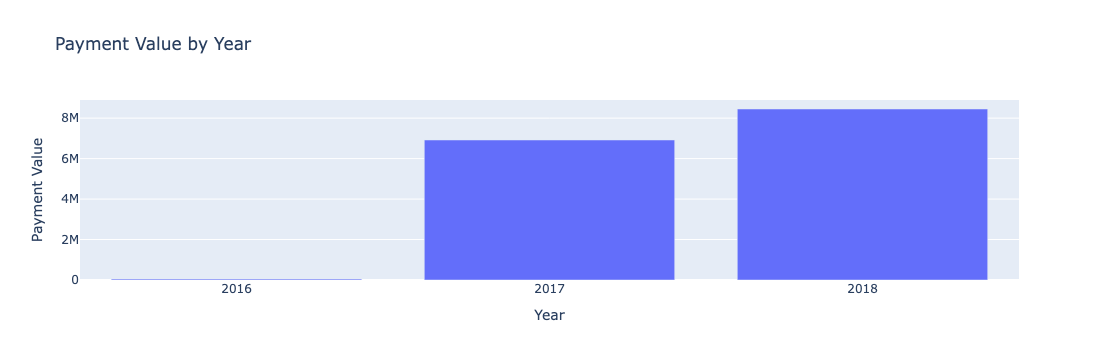

In [150]:
import plotly.express as px

fig = px.bar(
    x=merged_order_payment_year.index,
    y=merged_order_payment_year["payment_value"],
    title="Payment Value by Year",
    labels={
        "x": "Year",
        "y": "Payment Value"
    }
)

fig.update_xaxes(tickvals=[2016, 2017, 2018])

fig.show()

In [160]:
merged_order_payment_weekday = merged_order_payment_date[["weekday", "payment_value"]].copy()

In [161]:
merged_order_payment_weekday

,weekday,payment_value
0,0,38.71
1,1,141.46
2,2,179.12
3,5,72.20
4,1,28.62
...,...,...
96455,3,85.08
96456,1,195.00
96457,6,271.01
96458,0,441.16


In [153]:
merged_order_payment_weekday = merged_order_payment_weekday.groupby("weekday").sum()

In [154]:
merged_order_payment_weekday.head()

,payment_value
weekday,
0,2530671.56
1,2473930.77
2,2396215.34
3,2283849.51
4,2222421.36


In [155]:
def func(row) :
    if row["weekday"] == 0 :
        row["weekday"] = "Mon"
    elif row["weekday"] == 1 :
        row["weekday"] = "Tue"
    elif row["weekday"] == 2 :
        row["weekday"] = "Wed"
    elif row["weekday"] == 3 :
        row["weekday"] = "Thu"
    elif row["weekday"] == 4 :
        row["weekday"] = "Fri"
    elif row["weekday"] == 5 :
        row["weekday"] = "Sat"
    elif row["weekday"] == 6 :
        row["weekday"] = "Sun"
    return row

In [158]:
merged_order_payment_weekday.index

Index([0, 1, 2, 3, 4, 5, 6], dtype='int32', name='weekday')

In [165]:
merged_order_payment_weekday["weekday"] = merged_order_payment_weekday["weekday"].astype(object)
merged_order_payment_weekday = merged_order_payment_weekday.apply(func, axis=1)
merged_order_payment_weekday

,weekday,payment_value
0,Mon,38.71
1,Tue,141.46
2,Wed,179.12
3,Sat,72.20
4,Tue,28.62
...,...,...
96455,Thu,85.08
96456,Tue,195.00
96457,Sun,271.01
96458,Mon,441.16


In [164]:
merged_order_payment_weekday["weekday"]

0        0
1        1
2        2
3        5
4        1
        ..
96455    3
96456    1
96457    6
96458    0
96459    3
Name: weekday, Length: 96460, dtype: object

In [166]:
merged_order_payment_weekday = merged_order_payment_weekday.groupby("weekday").sum()

In [167]:
merged_order_payment_weekday

,payment_value
weekday,
Fri,2222421.36
Mon,2530671.56
Sat,1704949.69
Sun,1807644.62
Thu,2283849.51
Tue,2473930.77
Wed,2396215.34


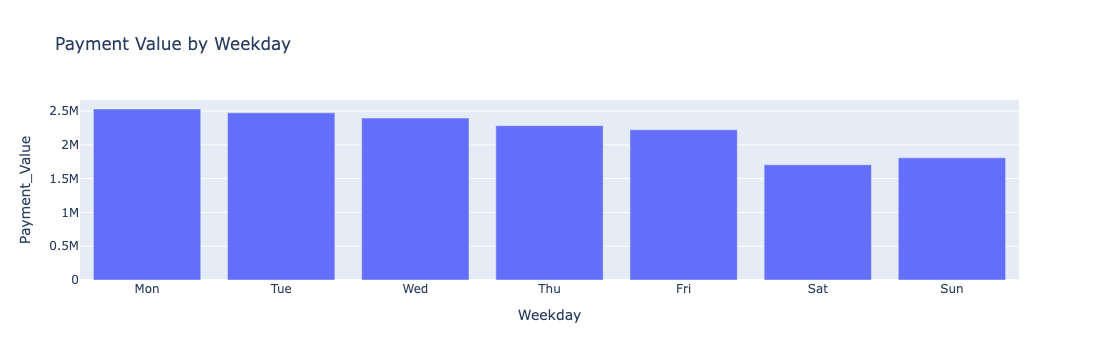

In [317]:
import plotly.express as px

fig = px.bar(
    x=merged_order_payment_weekday.index,
    y=merged_order_payment_weekday["payment_value"],
    category_orders={"x" : ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]},
    title="Payment Value by Weekday",
    labels={"x": "Weekday", "y" : "Payment_Value"}
)

fig.show()

In [327]:
merged_order_payment_quarter = merged_order_payment_date[["quarter", "payment_value"]].copy()

In [328]:
merged_order_payment_quarter.head()

,quarter,payment_value
0,4,38.71
1,3,141.46
2,3,179.12
3,4,72.20
4,1,28.62


In [338]:
merged_order_payment_quarter = merged_order_payment_quarter.groupby("quarter").sum()

In [341]:
merged_order_payment_quarter

,payment_value
quarter,
1,3977098.94
2,4721382.50
3,3926177.93
4,2795023.48


In [344]:
merged_order_payment_quarter = merged_order_payment_quarter.reset_index()

TypeError: 'Index' object is not callable

In [345]:
def func(row) :
    if row["quarter"] == 1 :
        row["quarter"] = "1Q"
    elif row["quarter"] == 2 :
        row["quarter"] = "2Q"
    elif row["quarter"] == 3 :
        row["quarter"] = "3Q"
    elif row["quarter"] == 4 :
        row["quarter"] = "4Q"
    return row

In [346]:
merged_order_payment_quarter["quarter"] = merged_order_payment_quarter["quarter"].astype(object)
merged_order_payment_quarter = merged_order_payment_quarter.apply(func, axis=1)
merged_order_payment_quarter

,quarter,payment_value
0,1Q,3977098.94
1,2Q,4721382.50
2,3Q,3926177.93
3,4Q,2795023.48


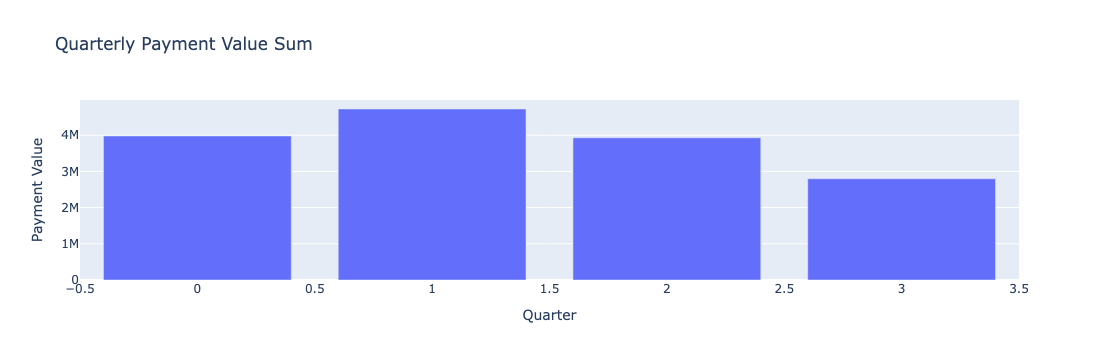

In [348]:
import plotly.express as px

fig = px.bar (
    x= merged_order_payment_quarter.index,
    y = merged_order_payment_quarter["payment_value"],
    title = "Quarterly Payment Value Sum",
    labels ={"x" : "Quarter", "y" : "Payment Value"}
)

fig.show()

In [350]:
merged_order_payment_hour = merged_order_payment_date[["hour", "payment_value"]].copy()

In [352]:
merged_order_payment_hour = merged_order_payment_hour.groupby("hour").sum()

In [353]:
merged_order_payment_hour

,payment_value
hour,
0,360158.45
1,171441.04
2,64572.21
3,37551.29
4,28209.97
5,25620.74
6,63215.01
7,173948.18
8,452343.96


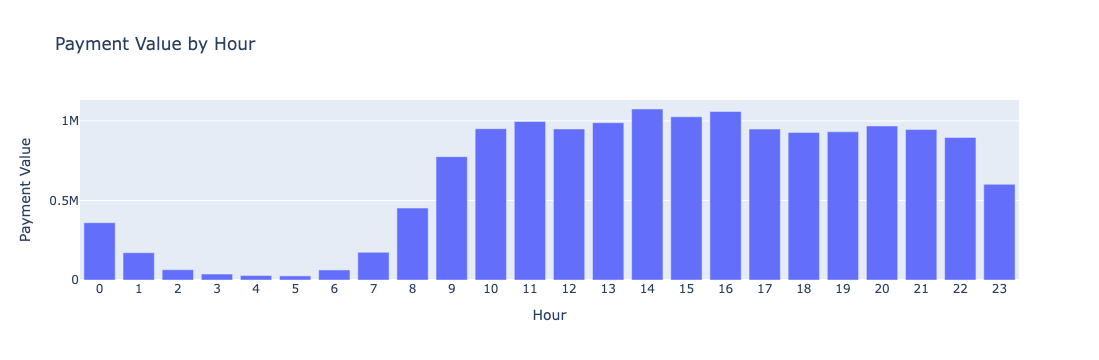

In [356]:
import plotly.express as px 

fig = px.bar(
    x=merged_order_payment_hour.index,
    y=merged_order_payment_hour["payment_value"],
    title= "Payment Value by Hour",
    labels={"x": "Hour", "y" : "Payment Value"}
)

fig.update_layout(
    xaxis={
        "dtick" : 1 
    }
)

fig.show()

In [357]:
merged_order_payment_minute = merged_order_payment_date[["minute", "payment_value"]].copy()

In [358]:
merged_order_payment_minute = merged_order_payment_minute.groupby("minute").sum()

In [359]:
merged_order_payment_minute 

,payment_value
minute,
0,253410.99
1,247286.12
2,220971.41
3,245626.28
4,265087.98
5,259540.04
6,257488.36
7,267940.45
8,271719.60


In [ ]:
import plotly.express as px 

fig = px.bar(
    x=merged_order_payment_minute.index,
    y=merged_order_payment_minute["payment_value"],
    title= "Payment Value by minute",
    labels={"x": "Hour", "y" : "Payment Value"}
)

fig.update_layout(
    xaxis={
        "dtick" : 1 
    }
)

fig.show()

In [14]:
merged_order_payment_date.head()

,order_purchase_timestamp,payment_value,year,month,day,weekday,hour,minute,quarter
0,2017-10-02 10:56:33,38.71,2017,10,2,0,10,56,4
1,2018-07-24 20:41:37,141.46,2018,7,24,1,20,41,3
2,2018-08-08 08:38:49,179.12,2018,8,8,2,8,38,3
3,2017-11-18 19:28:06,72.20,2017,11,18,5,19,28,4
4,2018-02-13 21:18:39,28.62,2018,2,13,1,21,18,1


In [ ]:
# 요일과 시간 간 거래액 관련 상관관계 파악!!!

In [17]:
merged_order_payment_hour_weekday = merged_order_payment_date[["weekday", "hour", "payment_value"]].copy()

In [18]:
merged_order_payment_hour_weekday

,weekday,hour,payment_value
0,0,10,38.71
1,1,20,141.46
2,2,8,179.12
3,5,19,72.20
4,1,21,28.62
...,...,...,...
96455,3,9,85.08
96456,1,12,195.00
96457,6,14,271.01
96458,0,21,441.16


In [19]:
merged_order_payment_hour_weekday = merged_order_payment_hour_weekday.groupby(["weekday", "hour"]).sum()

In [20]:
merged_order_payment_hour_weekday

payment_value
weekday hour               
0       0          46807.42
        1          17734.77
        2           7462.56
        3           6442.62
        4           2138.02
...                     ...
6       19        140127.39
        20        150543.96
        21        135431.31
        22        127866.74
        23         82991.95

[168 rows x 1 columns]

In [23]:
merged_order_payment_hour_weekday.index[3][0]

np.int32(0)

In [24]:
merged_order_payment_hour_weekday= merged_order_payment_hour_weekday.reset_index()

In [25]:
merged_order_payment_hour_weekday

,weekday,hour,payment_value
0,0,0,46807.42
1,0,1,17734.77
2,0,2,7462.56
3,0,3,6442.62
4,0,4,2138.02
...,...,...,...
163,6,19,140127.39
164,6,20,150543.96
165,6,21,135431.31
166,6,22,127866.74


In [26]:
def func(row) :
    if row["weekday"] == 0 :
        row["weekday"] = "Mon"
    elif row["weekday"] == 1 :
        row["weekday"] = "Tue"
    elif row["weekday"] == 2 :
        row["weekday"] = "Wed"
    elif row["weekday"] == 3 :
        row["weekday"] = "Thu"
    elif row["weekday"] == 4 :
        row["weekday"] = "Fri"
    elif row["weekday"] == 5 :
        row["weekday"] = "Sat"
    elif row["weekday"] == 6 :
        row["weekday"] = "Sun"
    return row

In [27]:
merged_order_payment_hour_weekday.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   weekday        168 non-null    int32  
 1   hour           168 non-null    int32  
 2   payment_value  168 non-null    float64
dtypes: float64(1), int32(2)
memory usage: 2.8 KB


In [28]:
merged_order_payment_hour_weekday["weekday"] =  merged_order_payment_hour_weekday["weekday"].astype(object)
merged_order_payment_hour_weekday = merged_order_payment_hour_weekday.apply(func, axis=1)
merged_order_payment_hour_weekday

,weekday,hour,payment_value
0,Mon,0,46807.42
1,Mon,1,17734.77
2,Mon,2,7462.56
3,Mon,3,6442.62
4,Mon,4,2138.02
...,...,...,...
163,Sun,19,140127.39
164,Sun,20,150543.96
165,Sun,21,135431.31
166,Sun,22,127866.74


In [29]:
merged_order_payment_hour_weekday.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   weekday        168 non-null    object 
 1   hour           168 non-null    int64  
 2   payment_value  168 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 4.1+ KB


In [31]:
merged_order_payment_hour_weekday["weekday"] = pd.Categorical(merged_order_payment_hour_weekday["weekday"], categories =["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"], ordered=True)

In [32]:
merged_order_payment_hour_weekday = merged_order_payment_hour_weekday.sort_values(by=["weekday", "hour"], ascending=True)

In [33]:
merged_order_payment_hour_weekday

,weekday,hour,payment_value
144,Sun,0,38888.45
145,Sun,1,20137.20
146,Sun,2,11965.82
147,Sun,3,6326.13
148,Sun,4,3914.48
...,...,...,...
139,Sat,19,115304.51
140,Sat,20,124346.60
141,Sat,21,100578.62
142,Sat,22,79660.03


In [ ]:
# 피어슨 상관계수 => 상관관계 관련 데이터 차트를 생성!!! 

In [35]:
doc =pd.read_csv("/Users/mac/Python_basic/Python_won/pandas/00_PANDASPLOTLY_FUNCODING_FIRSTDATA/COVID-19-master/csse_covid_19_daily_reports/04-01-2020.csv", encoding="utf-8-sig")

In [36]:
doc

,FIPS,Admin2,Province_State,Country_Region,Last_Update,Lat,Long_,Confirmed,Deaths,Recovered,Active,Combined_Key
0,45001.0,Abbeville,South Carolina,US,2020-04-01 21:58:49,34.223334,-82.461707,4,0,0,4,"Abbeville, South Carolina, US"
1,22001.0,Acadia,Louisiana,US,2020-04-01 21:58:49,30.295065,-92.414197,47,1,0,46,"Acadia, Louisiana, US"
2,51001.0,Accomack,Virginia,US,2020-04-01 21:58:49,37.767072,-75.632346,7,0,0,7,"Accomack, Virginia, US"
3,16001.0,Ada,Idaho,US,2020-04-01 21:58:49,43.452658,-116.241552,195,3,0,192,"Ada, Idaho, US"
4,19001.0,Adair,Iowa,US,2020-04-01 21:58:49,41.330756,-94.471059,1,0,0,1,"Adair, Iowa, US"
...,...,...,...,...,...,...,...,...,...,...,...,...
2517,82604.0,NaN,Wales,United Kingdom,2020-04-01 21:58:49,52.130700,-3.783700,0,198,0,0,"Wales, United Kingdom"
2518,NaN,NaN,NaN,Nauru,2020-04-01 21:58:49,-0.522800,166.931500,0,0,0,0,Nauru
2519,NaN,NaN,Niue,New Zealand,2020-04-01 21:58:49,-19.054400,-169.867200,0,0,0,0,"Niue, New Zealand"
2520,NaN,NaN,NaN,Tuvalu,2020-04-01 21:58:49,-7.109500,177.649300,0,0,0,0,Tuvalu


In [47]:
doc2 = doc.corr(numeric_only=True)

In [48]:
doc2

,FIPS,Lat,Long_,Confirmed,Deaths,Recovered,Active
FIPS,1.000000,0.160717,0.171490,-0.000504,0.076467,NaN,0.002718
Lat,0.160717,1.000000,-0.476426,0.029389,0.026309,-0.002781,0.035631
Long_,0.171490,-0.476426,1.000000,0.141126,0.096924,0.141932,0.119737
Confirmed,-0.000504,0.029389,0.141126,1.000000,0.837153,0.727305,0.942484
Deaths,0.076467,0.026309,0.096924,0.837153,1.000000,0.546858,0.796549
Recovered,NaN,-0.002781,0.141932,0.727305,0.546858,1.000000,0.462484
Active,0.002718,0.035631,0.119737,0.942484,0.796549,0.462484,1.000000


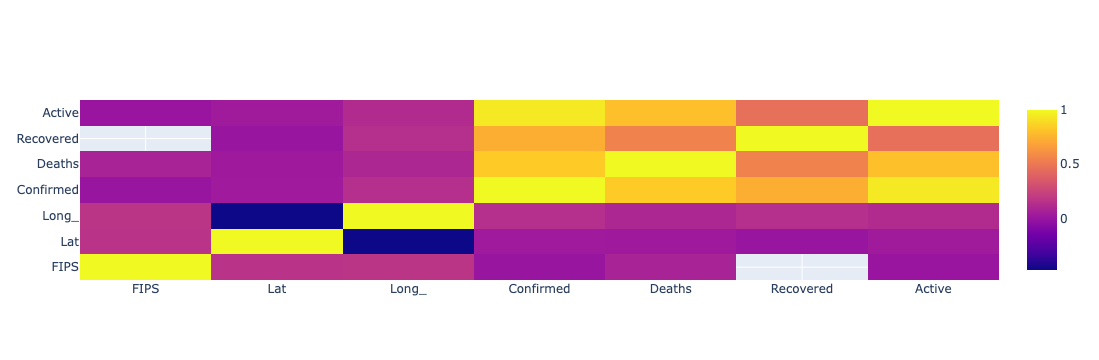

In [50]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Heatmap(
        x=doc2.columns,
        y=doc2.index,
        z=doc2.values
    )
)

fig.show()

In [51]:
pivot_df = merged_order_payment_hour_weekday.pivot(index="weekday", columns="hour", values="payment_value")

In [52]:
pivot_df

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
weekday,,,,,,,,,,,,,,,,,,,,,
Sun,38888.45,20137.20,11965.82,6326.13,3914.48,3447.12,3585.66,17573.93,34162.64,62017.80,...,110684.66,113924.78,101793.38,120192.87,135174.00,140127.39,150543.96,135431.31,127866.74,82991.95
Mon,46807.42,17734.77,7462.56,6442.62,2138.02,2915.84,6919.09,21337.29,74426.66,126803.08,...,177222.03,170009.12,169767.51,149143.91,140315.41,155189.14,162640.98,174686.78,165825.81,115206.30
Tue,46897.54,23357.21,9775.06,5766.02,4011.98,2484.91,9227.46,29786.34,72203.85,142565.22,...,179894.40,156461.77,169351.75,154063.37,137553.19,142172.41,158487.95,157607.06,153639.92,103570.97
Wed,63141.49,25237.54,10306.86,3940.09,3377.50,3064.79,11195.02,31649.26,78790.60,136024.62,...,175344.71,154366.92,171016.54,154152.53,151608.09,125440.09,131817.40,134793.75,128446.03,82444.91
Thu,56597.74,21924.09,10437.10,5352.42,4443.58,3153.73,9361.32,29474.64,79696.57,116088.58,...,148986.01,148628.26,166728.41,140905.10,129388.17,133507.77,132913.67,132110.46,136137.46,82126.03
Fri,64598.76,39847.96,6382.38,5574.33,5105.33,7387.34,13410.84,26897.02,75112.12,122018.59,...,160856.20,162302.84,174806.20,122901.80,120989.77,120148.30,107523.62,110692.47,104741.69,76129.27
Sat,43227.05,23202.27,8242.43,4149.68,5219.08,3167.01,9515.62,17229.70,37951.52,69616.10,...,122126.94,120692.06,105854.14,107603.02,112778.27,115304.51,124346.60,100578.62,79660.03,59000.30


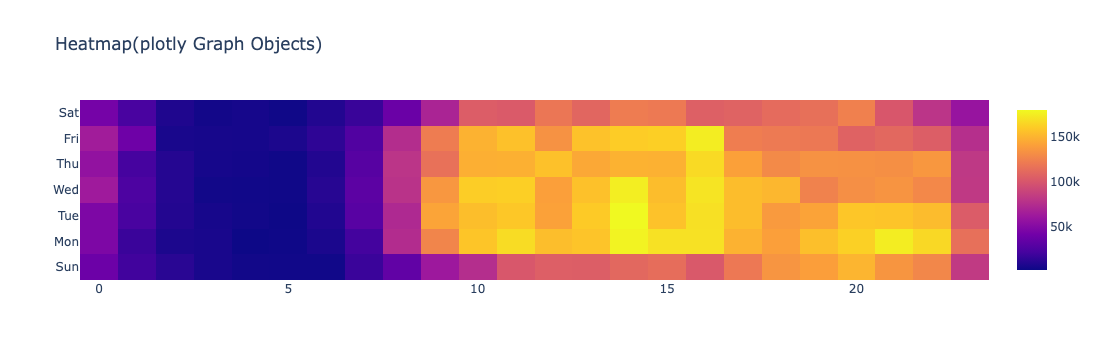

In [57]:
import plotly.graph_objects as go

fig = go.Figure(
    go.Heatmap(
        x=pivot_df.columns,
        y=pivot_df.index,
        z=pivot_df.values
        
    )
)

fig.update_layout(
    title={
        "text":"Heatmap(plotly Graph Objects)"
    }
)

fig.show()

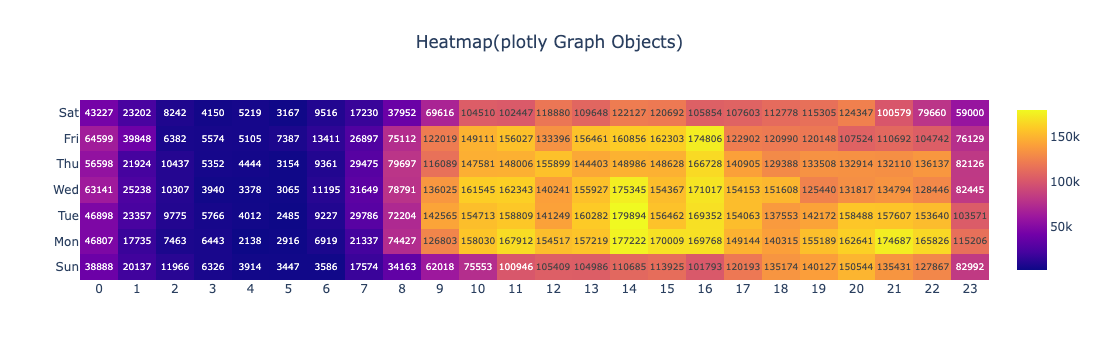

In [64]:
import plotly.graph_objects as go

fig = go.Figure(
    go.Heatmap(
        x=pivot_df.columns,
        y=pivot_df.index,
        z=pivot_df.values,
        text = pivot_df.values,
        texttemplate="%{z:.0f}"
        
    )
)

fig.update_layout(
    title={
        "text":"Heatmap(plotly Graph Objects)",
        "x": 0.5,
        "y": 0.9
    },
    xaxis=dict(
        dtick=1,
        
    )
)

fig.show()

In [ ]:
#어떤 카테고리가 가장 많은 주문건수 (여기서만 매출로 본다)을 발생시켰는지 

In [148]:
products = pd.read_csv(f"{PATH}olist_products_dataset.csv", encoding="utf-8-sig")
customers = pd.read_csv(f"{PATH}olist_customers_dataset.csv", encoding="utf-8-sig")
geolocation = pd.read_csv(f"{PATH}olist_geolocation_dataset.csv", encoding="utf-8-sig")
order_items = pd.read_csv(f"{PATH}olist_order_items_dataset.csv", encoding="utf-8-sig")
payments = pd.read_csv(f"{PATH}olist_order_payments_dataset.csv", encoding="utf-8-sig")
reviews = pd.read_csv(f"{PATH}olist_order_reviews_dataset.csv", encoding="utf-8-sig")
orders = pd.read_csv(f"{PATH}olist_orders_dataset.csv", encoding="utf-8-sig")
sellers = pd.read_csv(f"{PATH}olist_sellers_dataset.csv", encoding="utf-8-sig")
category_name = pd.read_csv(f"{PATH}product_category_name_translation.csv", encoding="utf-8-sig")

In [130]:
category_name

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
...,...,...
66,flores,flowers
67,artes_e_artesanato,arts_and_craftmanship
68,fraldas_higiene,diapers_and_hygiene
69,fashion_roupa_infanto_juvenil,fashion_childrens_clothes


In [67]:
products

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [68]:
payments

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


In [149]:
products_category = pd.merge(products, category_name, on="product_category_name")

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares
...,...,...,...,...,...,...,...,...,...,...
32323,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0,furniture_decor
32324,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0,construction_tools_lights
32325,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0,bed_bath_table
32326,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0,computers_accessories


In [150]:
products_category_only = products_category[["product_id", "product_category_name_english"]].copy()

In [134]:
products_category_only

,product_id,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,art
2,96bd76ec8810374ed1b65e291975717f,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,baby
4,9dc1a7de274444849c219cff195d0b71,housewares
...,...,...
32323,a0b7d5a992ccda646f2d34e418fff5a0,furniture_decor
32324,bf4538d88321d0fd4412a93c974510e6,construction_tools_lights
32325,9a7c6041fa9592d9d9ef6cfe62a71f8c,bed_bath_table
32326,83808703fc0706a22e264b9d75f04a2e,computers_accessories


In [135]:
products_category_only.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32328 entries, 0 to 32327
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_id                     32328 non-null  object
 1   product_category_name_english  32328 non-null  object
dtypes: object(2)
memory usage: 505.3+ KB


In [74]:
products_category_only.isnull().sum()

product_id                       0
product_category_name_english    0
dtype: int64

In [76]:
order_items

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [80]:
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [151]:
product_category_order = pd.merge(products_category_only, order_items, on="product_id")

In [82]:
product_category_order

,product_id,product_category_name_english,order_id,order_item_id,seller_id,shipping_limit_date,price,freight_value
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumery,e17e4f88e31525f7deef66779844ddce,1,5670f4db5b62c43d542e1b2d56b0cf7c,2018-04-30 17:33:54,10.91,7.39
1,3aa071139cb16b67ca9e5dea641aaa2f,art,5236307716393b7114b53ee991f36956,1,b561927807645834b59ef0d16ba55a24,2018-02-06 19:11:15,248.00,17.99
2,96bd76ec8810374ed1b65e291975717f,sports_leisure,01f66e58769f84129811d43eefd187fb,1,7b07b3c7487f0ea825fc6df75abd658b,2018-07-11 21:30:20,79.80,7.82
3,cef67bcfe19066a932b7673e239eb23d,baby,143d00a4f2dde4e0364ee1821577adb3,1,c510bc1718f0f2961eaa42a23330681a,2018-08-07 09:10:13,112.30,9.54
4,9dc1a7de274444849c219cff195d0b71,housewares,86cafb8794cb99a9b1b77fc8e48fbbbb,1,0be8ff43f22e456b4e0371b2245e4d01,2018-04-17 01:30:23,37.90,8.29
...,...,...,...,...,...,...,...,...
111018,83808703fc0706a22e264b9d75f04a2e,computers_accessories,59e88b7d3675e89aceaf86f372d3bc9a,2,4324dd16853115efb0fd9d0d131ba6f4,2018-01-10 03:32:09,29.90,16.11
111019,83808703fc0706a22e264b9d75f04a2e,computers_accessories,6e4465d771f02e4fe335225de3c6c043,1,4324dd16853115efb0fd9d0d131ba6f4,2018-03-14 02:30:48,29.90,23.28
111020,83808703fc0706a22e264b9d75f04a2e,computers_accessories,6e4465d771f02e4fe335225de3c6c043,2,4324dd16853115efb0fd9d0d131ba6f4,2018-03-14 02:30:48,29.90,23.28
111021,83808703fc0706a22e264b9d75f04a2e,computers_accessories,6e4465d771f02e4fe335225de3c6c043,3,4324dd16853115efb0fd9d0d131ba6f4,2018-03-14 02:30:48,29.90,23.28


In [137]:
# 커스터마이징 할 수 있는 집계함수를 사용가능 = > 그룹바이 + 집계함수 => 모든 컬럼이 동일한 집계

#예시 

df = pd.DataFrame({
    "미국" : [2.1, 2.2, 2.3],
    "한국" : [0.4, 0.5, 0.45],
    "중국" : [10, 13, 15]
})

df

,미국,한국,중국
0,2.1,0.40,10
1,2.2,0.50,13
2,2.3,0.45,15


In [84]:
df.aggregate(["sum", "min"]) #sum, min, max, mean,std, count

,미국,한국,중국
sum,6.6,1.35,38
min,2.1,0.40,10


In [85]:
df.agg({"미국":"count", "한국":"sum"})

미국    3.00
한국    1.35
dtype: float64

In [86]:
df.aggregate(["mean"])

,미국,한국,중국
mean,2.2,0.45,12.666667


In [87]:
df.agg("mean",axis="columns")

0    4.166667
1    5.233333
2    5.916667
dtype: float64

In [88]:
df = pd.DataFrame({
    "년도" : [2000,2010,2020,2000,2000,2000],
    "미국" : [2.1, 2.2, 2.3, 3.1, 4.1, 5.1],
    "한국" : [0.4,0.5,0.45,0.7,0.9,1.2],
    "중국" : [10, 13, 15, 12, 45, 56]
})

df

,년도,미국,한국,중국
0,2000,2.1,0.40,10
1,2010,2.2,0.50,13
2,2020,2.3,0.45,15
3,2000,3.1,0.70,12
4,2000,4.1,0.90,45
5,2000,5.1,1.20,56


In [89]:
df.groupby("년도").sum()

,미국,한국,중국
년도,,,
2000,14.4,3.20,123
2010,2.2,0.50,13
2020,2.3,0.45,15


In [92]:
df.groupby("년도").agg({"미국" : "sum", "한국":"mean"})

,미국,한국
년도,,
2000,14.4,0.80
2010,2.2,0.50
2020,2.3,0.45


In [152]:
product_category_order=product_category_order.groupby("product_category_name_english").agg({"order_id" : "count"}).rename(columns={"order_id" : "order_count"})

In [153]:
product_category_order

,order_count
product_category_name_english,
agro_industry_and_commerce,212
air_conditioning,297
art,209
arts_and_craftmanship,24
audio,364
...,...
stationery,2517
tablets_printing_image,83
telephony,4545


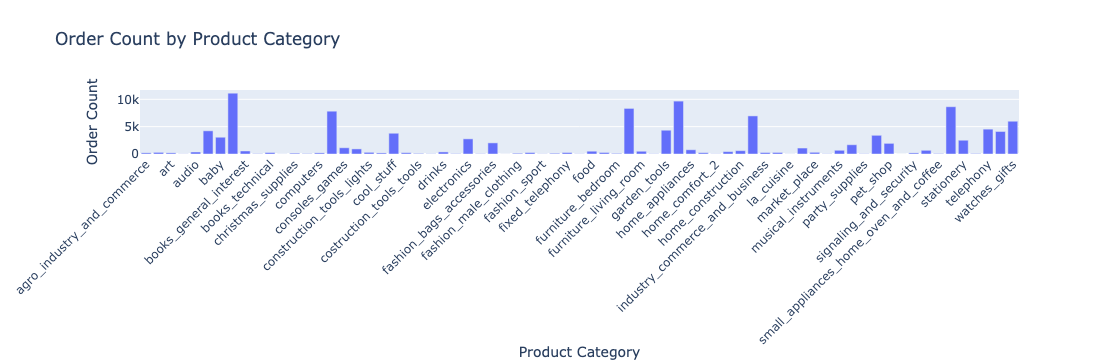

In [154]:
import plotly.express as px 

fig = px.bar(
    x=product_category_order.index,
    y=product_category_order["order_count"],
    title="Order Count by Product Category",
    labels={
        "x" : "Product Category",
        "y" : "Order Count"
    }
)

fig.update_layout(xaxis_tickangle=-45)

fig.show()

In [155]:
product_category_order = product_category_order.sort_values(by="order_count", ascending=False)

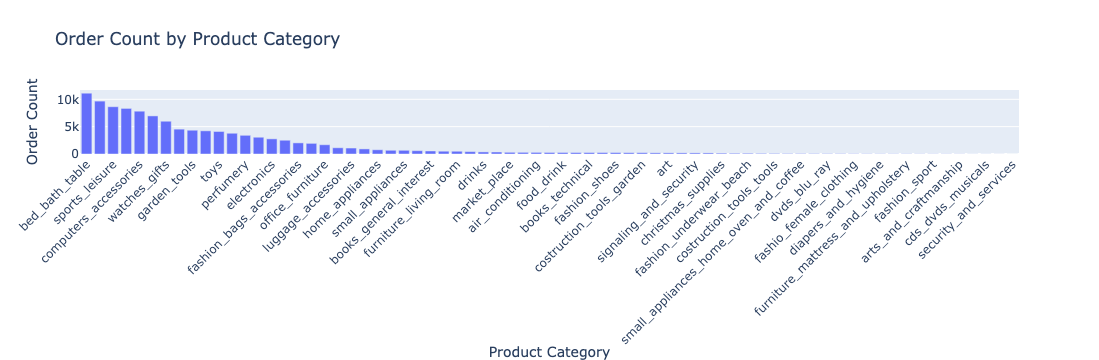

In [156]:
import plotly.express as px 

fig = px.bar(
    x=product_category_order.index,
    y=product_category_order["order_count"],
    title="Order Count by Product Category",
    labels={
        "x" : "Product Category",
        "y" : "Order Count"
    }
)

fig.update_layout(xaxis_tickangle=-45)

fig.show()

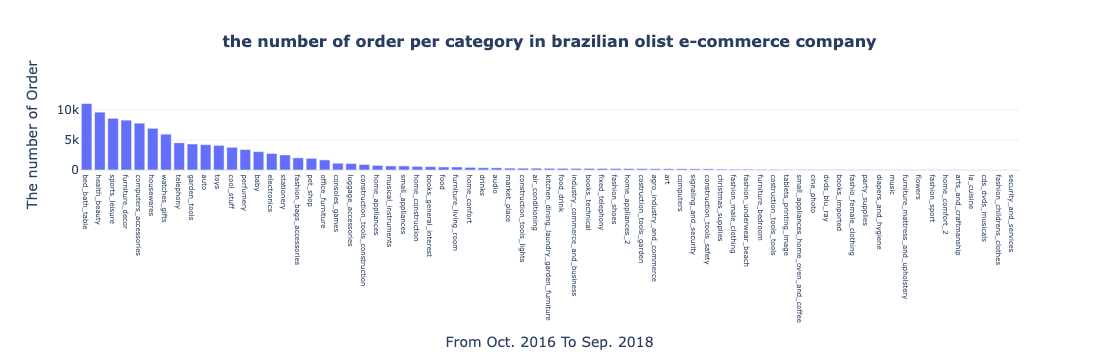

In [157]:
import plotly.express as px 

fig = px.bar(
    x=product_category_order.index,
    y=product_category_order["order_count"],
    title="Order Count by Product Category",
    labels={
        "x" : "Product Category",
        "y" : "Order Count"
    }
)

fig.update_layout({
    "title" : {
        "text" : "<b>the number of order per category in brazilian olist e-commerce company</b>",
        "x" : 0.5,
        "y" : 0.9,
        "font" : {
            "size" : 16
        }
    },
    "xaxis" : {
        "title" : "From Oct. 2016 To Sep. 2018",
        "showticklabels" : True, 
        "tickfont" : {
            "size" : 7
        }
    },
    "yaxis" : {
        "title" : "The number of Order"
        
    },
    "template" : "plotly_white"
})

fig.show()

In [159]:
product_category_order = product_category_order[product_category_order["order_count"] > 1000]

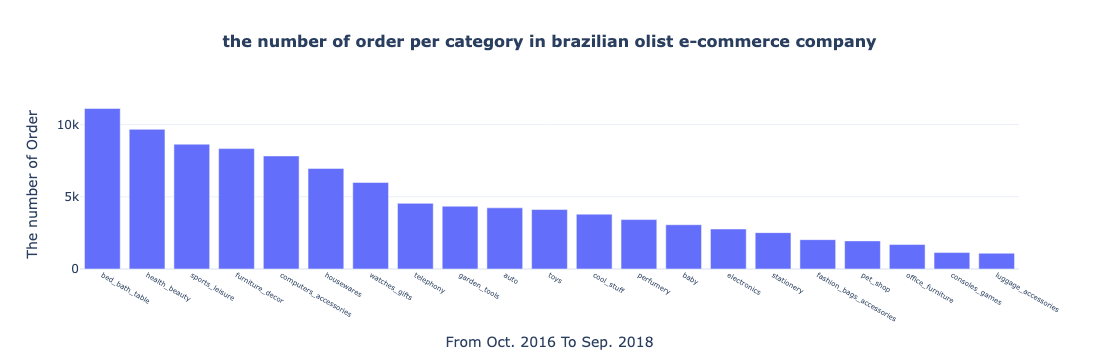

In [160]:
import plotly.express as px 

fig = px.bar(
    x=product_category_order.index,
    y=product_category_order["order_count"],
    title="Order Count by Product Category",
    labels={
        "x" : "Product Category",
        "y" : "Order Count"
    }
)

fig.update_layout({
    "title" : {
        "text" : "<b>the number of order per category in brazilian olist e-commerce company</b>",
        "x" : 0.5,
        "y" : 0.9,
        "font" : {
            "size" : 16
        }
    },
    "xaxis" : {
        "title" : "From Oct. 2016 To Sep. 2018",
        "showticklabels" : True, 
        "tickfont" : {
            "size" : 7
        }
    },
    "yaxis" : {
        "title" : "The number of Order"
        
    },
    "template" : "plotly_white"
})

fig.show()

In [ ]:
# 평균 배송시간

In [162]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [163]:
orders.shape

(99441, 8)

In [164]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [165]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [166]:
orders = orders.dropna()

In [167]:
orders.isnull().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64

In [170]:
orders["delivery_time"] = pd.to_datetime(orders["order_delivered_customer_date"]) - pd.to_datetime(orders["order_purchase_timestamp"])

/var/folders/bx/fx7kn8bn3tb0mgk1kklkjl2c0000gn/T/ipykernel_9470/4080963164.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [171]:
orders_new = orders.copy()

In [172]:
orders_new

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,8 days 10:28:40
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,13 days 18:46:08
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,9 days 09:27:40
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,13 days 05:00:36
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,2 days 20:58:23
...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00,8 days 05:13:56
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,22 days 04:38:58
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,24 days 20:37:34
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,17 days 02:04:27


In [173]:
orders_new["delivery_time"] = pd.to_datetime(orders["order_delivered_customer_date"]) - pd.to_datetime(orders["order_purchase_timestamp"])

In [174]:
orders_new

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,8 days 10:28:40
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,13 days 18:46:08
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,9 days 09:27:40
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,13 days 05:00:36
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,2 days 20:58:23
...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00,8 days 05:13:56
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,22 days 04:38:58
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,24 days 20:37:34
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,17 days 02:04:27


In [175]:
orders_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96461 entries, 0 to 99440
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype          
---  ------                         --------------  -----          
 0   order_id                       96461 non-null  object         
 1   customer_id                    96461 non-null  object         
 2   order_status                   96461 non-null  object         
 3   order_purchase_timestamp       96461 non-null  object         
 4   order_approved_at              96461 non-null  object         
 5   order_delivered_carrier_date   96461 non-null  object         
 6   order_delivered_customer_date  96461 non-null  object         
 7   order_estimated_delivery_date  96461 non-null  object         
 8   delivery_time                  96461 non-null  timedelta64[ns]
dtypes: object(8), timedelta64[ns](1)
memory usage: 7.4+ MB


In [176]:
orders_new["delivery_time"].describe()

count                         96461
mean     12 days 13:23:46.585853350
std       9 days 13:06:45.121880865
min                 0 days 12:48:07
25%                 6 days 18:22:50
50%                10 days 05:11:29
75%                15 days 17:17:10
max               209 days 15:05:12
Name: delivery_time, dtype: object

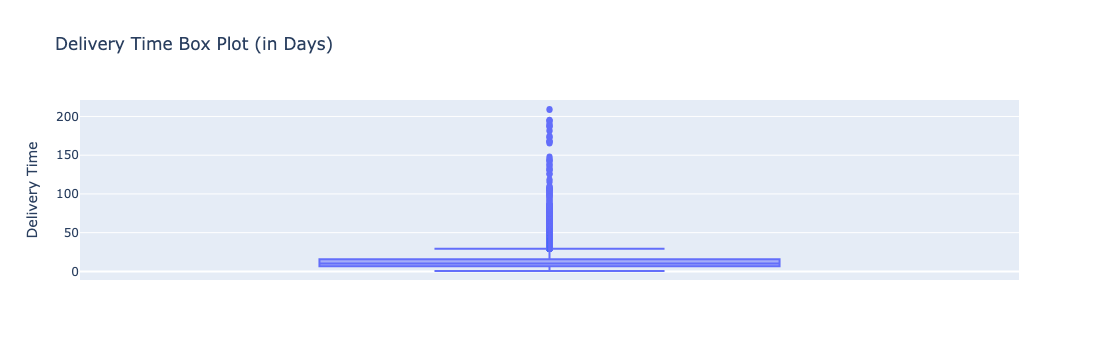

In [185]:
import plotly.express as px 

orders_new["delivery_time_days"] = orders_new["delivery_time"].dt.total_seconds() / 86400

fig = px.box(
    orders_new, 
    y="delivery_time_days",
    title ="Delivery Time Box Plot (in Days)",
    labels={
        "delivery_time_days" : "Delivery Time"
    }
)

fig.show()

In [190]:
#quantile() : 특정 데이터 내 원하는 값만 쪼개서 확인할 수 있도록 도와주는 함수

delivery_time_q95 = orders_new["delivery_time"].quantile(0.95)

In [188]:
delivery_time_q95

Timedelta('29 days 06:36:33')

In [191]:
delivery_time_q90 = orders_new["delivery_time"].quantile(0.9)

In [192]:
delivery_time_q90

Timedelta('23 days 02:21:07')

In [193]:
orders_new = orders_new[orders_new["delivery_time"] < delivery_time_q95]

In [194]:
orders_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 91637 entries, 0 to 99440
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype          
---  ------                         --------------  -----          
 0   order_id                       91637 non-null  object         
 1   customer_id                    91637 non-null  object         
 2   order_status                   91637 non-null  object         
 3   order_purchase_timestamp       91637 non-null  object         
 4   order_approved_at              91637 non-null  object         
 5   order_delivered_carrier_date   91637 non-null  object         
 6   order_delivered_customer_date  91637 non-null  object         
 7   order_estimated_delivery_date  91637 non-null  object         
 8   delivery_time                  91637 non-null  timedelta64[ns]
 9   delivery_time_days             91637 non-null  float64        
dtypes: float64(1), object(8), timedelta64[ns](1)
memory usage: 7.7+ MB


In [195]:
orders_new

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,delivery_time_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,8 days 10:28:40,8.436574
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,13 days 18:46:08,13.782037
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,9 days 09:27:40,9.394213
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,13 days 05:00:36,13.208750
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,2 days 20:58:23,2.873877
...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00,8 days 05:13:56,8.218009
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,22 days 04:38:58,22.193727
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,24 days 20:37:34,24.859421
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,17 days 02:04:27,17.086424


In [203]:
orders_date = orders_new[["order_purchase_timestamp", "delivery_time"]].copy()
orders_date["order_purchase_timestamp"] = pd.to_datetime(orders_date["order_purchase_timestamp"], format="%Y-%m-%d %H:%M:%S", errors="raise")
orders_date["delivery_time"] = orders_date["delivery_time"].dt.total_seconds()
orders_date = orders_date.set_index("order_purchase_timestamp")

In [204]:
orders_date

,delivery_time
order_purchase_timestamp,
2017-10-02 10:56:33,728920.0
2018-07-24 20:41:37,1190768.0
2018-08-08 08:38:49,811660.0
2017-11-18 19:28:06,1141236.0
2018-02-13 21:18:39,248303.0
...,...
2017-03-09 09:54:05,710036.0
2018-02-06 12:58:58,1917538.0
2017-08-27 14:46:43,2147854.0


In [205]:
orders_date.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 91637 entries, 2017-10-02 10:56:33 to 2018-03-08 20:57:30
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   delivery_time  91637 non-null  float64
dtypes: float64(1)
memory usage: 1.4 MB


In [207]:
orders_date.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 91637 entries, 2017-10-02 10:56:33 to 2018-03-08 20:57:30
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   delivery_time  91637 non-null  float64
dtypes: float64(1)
memory usage: 1.4 MB


In [209]:
orders_date = orders_date.groupby(pd.Grouper(freq="ME")).mean()

In [210]:
orders_date

,delivery_time
order_purchase_timestamp,
2016-10-31,1.293386e+06
2016-11-30,NaN
2016-12-31,4.054770e+05
2017-01-31,9.549751e+05
2017-02-28,1.010813e+06
2017-03-31,9.495985e+05
2017-04-30,1.128281e+06
2017-05-31,9.224197e+05
2017-06-30,9.701143e+05


In [ ]:
#지수표기법 : 부동소수점을 가지고 있는 실수자료형에서 많이 사용하는 표기법 
# 1.12313243567453421 (*정수부 > 실수부)
# 숫자 비교, 크기 => 실수부 < 정수부
# 제곱 => 밑 / 지수 2^3 

# 6.626825e+05 => 6.626825 x 10^5 (100000)
# 부호부 (1비트) x 값 (55비트) x 지수부 (8비트)

# 0000000 0000000 0000000 0000000 0000000 0000000 000000

In [211]:
orders_date["delivery_time"] = orders_date["delivery_time"] / 86400

In [212]:
orders_date

,delivery_time
order_purchase_timestamp,
2016-10-31,14.969742
2016-11-30,NaN
2016-12-31,4.693021
2017-01-31,11.052953
2017-02-28,11.699220
2017-03-31,10.990723
2017-04-30,13.058808
2017-05-31,10.676153
2017-06-30,11.228175


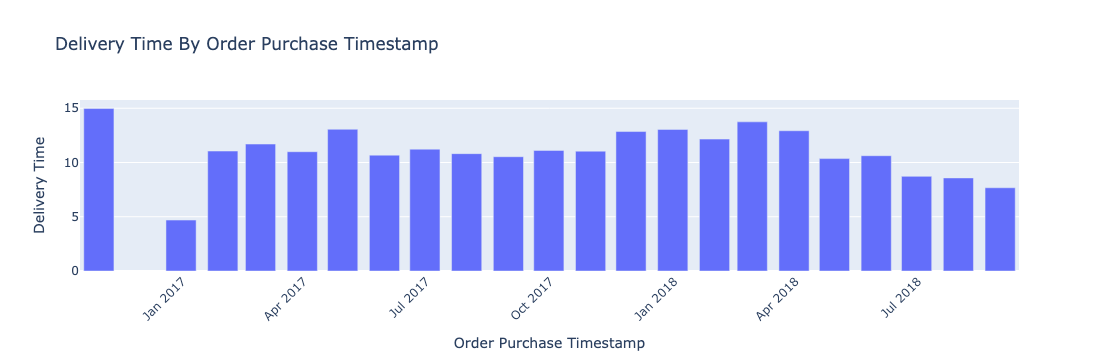

In [216]:
import plotly.express as px 

fig = px.bar(
    x=orders_date.index,
    y=orders_date["delivery_time"],
    title = "Delivery Time By Order Purchase Timestamp",
    labels = {
        "x" : "Order Purchase Timestamp",
        "y" : "Delivery Time"
    }
)

fig.update_layout(xaxis_tickangle=-45)


fig.show()

In [217]:
orders_date = orders_date[orders_date.index > "2017-01-01"]

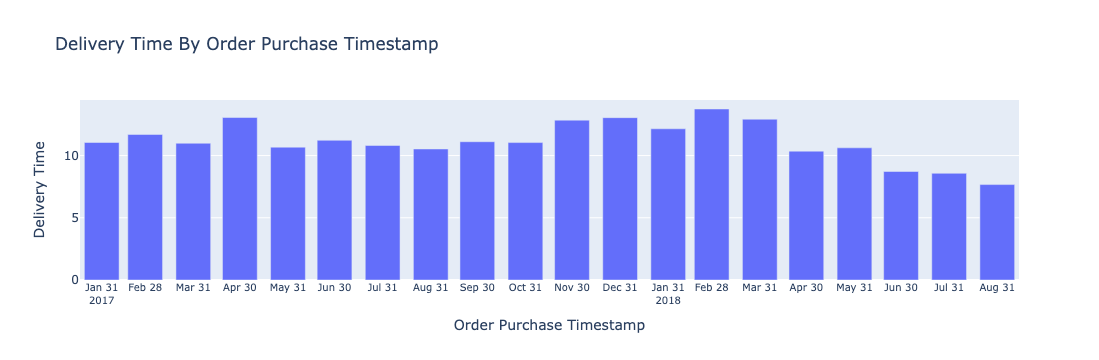

In [229]:
import plotly.express as px 

fig = px.bar(
    x=orders_date.index,
    y=orders_date["delivery_time"],
    title = "Delivery Time By Order Purchase Timestamp",
    labels = {
        "x" : "Order Purchase Timestamp",
        "y" : "Delivery Time"
    }
)

fig.update_layout(
    xaxis = {
        "showticklabels" : True,
        "dtick" : "M1",
        "tick0" : "2017-01-31",
        "tickfont" : {
            "size" : 10
        }
    }
)


fig.show()

In [230]:
colors = ["#1b80bf"] * len(orders_date.index)
for index in range(15, len(orders_date.index)) :
    colors[index] = "#bf2c47"

In [231]:
colors

['#1b80bf',
 '#1b80bf',
 '#1b80bf',
 '#1b80bf',
 '#1b80bf',
 '#1b80bf',
 '#1b80bf',
 '#1b80bf',
 '#1b80bf',
 '#1b80bf',
 '#1b80bf',
 '#1b80bf',
 '#1b80bf',
 '#1b80bf',
 '#1b80bf',
 '#bf2c47',
 '#bf2c47',
 '#bf2c47',
 '#bf2c47',
 '#bf2c47']

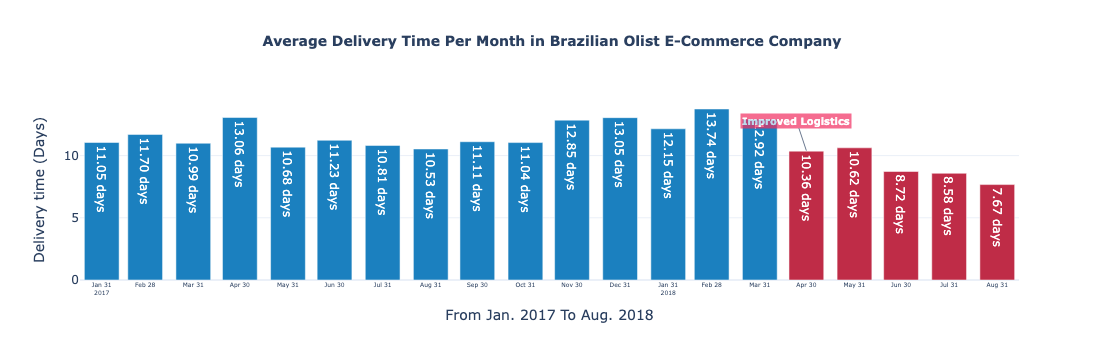

In [244]:
import plotly.graph_objects as go 

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=orders_date.index,
        y=orders_date["delivery_time"],
        text=orders_date["delivery_time"],
        texttemplate="%{text:.2f} days",
        marker_color=colors
    )
)

fig.update_layout({
    "title": {
        "text" : "<b> Average Delivery Time Per Month in Brazilian Olist E-Commerce Company</b>",
        "x" : 0.5,
        "y" : 0.9,
        "font" : {
            "size" : 14
        }
    },
    "xaxis": {
        "title" : "From Jan. 2017 To Aug. 2018",
        "showticklabels" : True,
        "tick0" : "2017-01-31",
        "dtick" : "M1",
        "tickfont" : {
            "size" : 6
        }
    },
    "yaxis": {
        "title" : "Delivery time (Days)"
    },
    "template" : "plotly_white"
})

fig.add_annotation(
    x="2018-04-30",
    y=10.4,
    text= "<b>Improved Logistics</b>",
    showarrow=True,
    font={
        "size": 10,
        "color" : "#fff"
    },
    bgcolor="#f22e62",
    opacity=0.7
)

fig.show()